# Veri Madenciliği Final Projesi — Bölüm 2: Modelleme, Değerlendirme ve İyileştirme

**Ders:** MIS643 Veri Madenciliği (Lisansüstü)
**Öğrenci:** Dilber Cansu TORAMAN — 25220903022

Bu defter, `data_prep` defterinin ürettiği `student_data_processed.csv` dosyasını yükler ve **vize çalışmasından farklı, daha gelişmiş** bir modelleme akışı yürütür.

> **Vize ile fark:** Vize aşamasında temel modeller (Lojistik Regresyon, Karar Ağacı, Random Forest) kullanılmıştı. Final aşamasında bunlar **kullanılmamış**; bunun yerine **gelişmiş topluluk (ensemble) yöntemleri** (Gradient Boosting, HistGradientBoosting, AdaBoost, Extra Trees, Stacking), bir **çekirdek yöntemi** (SVM-RBF), bir **örnek-temelli yöntem** (KNN) ve bir **derin öğrenme** modeli (çok katmanlı yapay sinir ağı, MLP) uygulanmıştır.

**Akış:**
1. Eğitim / test ayrımı (test seti yalnızca en sonda)
2. Ön işleme + özellik seçimi işlem hattı (pipeline)
3. Gelişmiş, **vizeden farklı** sekiz algoritma
4. 5 katlı tabakalı çapraz doğrulama ile çoklu metrik karşılaştırması
5. Hiperparametre optimizasyonu (GridSearchCV)
6. ROC eğrileri (çok sınıflı, OvR) ve karmaşıklık matrisleri
7. Özellik önemleri ve nihai test değerlendirmesi
8. **COURSE ID'siz sağlamlık kontrolü** — modelin ders kimliğine bağımlılığının sınanması
9. **Gözetimsiz kümeleme analizi (KMeans)** — farklı bir bakış açısı

## 1. Kütüphaneler

Tüm modelleme `scikit-learn` ile yapılır. Gelişmiş topluluk yöntemleri, sinir ağı (MLP) ve kümeleme için ilgili modüller içe aktarılır.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.inspection import permutation_importance
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, auc,
                             silhouette_score, adjusted_rand_score)

# Gelismis topluluk yontemleri + cekirdek + ornek-temelli + derin ogrenme
from sklearn.ensemble import (GradientBoostingClassifier, HistGradientBoostingClassifier,
                              AdaBoostClassifier, ExtraTreesClassifier, StackingClassifier)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression  # yalnizca Stacking meta-ogrenicisi olarak
from sklearn.cluster import KMeans

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
print("Kutuphaneler yuklendi. scikit-learn ile gelismis modelleme.")

Kutuphaneler yuklendi. scikit-learn ile gelismis modelleme.


## 2. İşlenmiş Verinin Yüklenmesi

`data_prep` defterinin sonunda kaydedilen, temizlenmiş ve özellik mühendisliği yapılmış veri okunur.

In [2]:
df = pd.read_csv("student_data_processed.csv")
print("Boyut:", df.shape)
print("Sinif dagilimi:")
print(df["basari_duzeyi"].value_counts().reindex(["Dusuk", "Orta", "Yuksek"]).to_string())
display(df.head())

Boyut: (145, 36)
Sinif dagilimi:
basari_duzeyi
Dusuk     67
Orta      48
Yuksek    30


,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,COURSE ID,soru_toplam,soru_ortalama,soru_std,GRADE,basari_duzeyi
0,2,2,3,3,1,2,2,1,1,1,1,2,3,1,2,5,3,2,2,1,1,1,1,1,3,2,1,2,1,1,1,54,1.800000,0.961321,1,Dusuk
1,2,2,3,3,1,2,2,1,1,1,2,3,2,1,2,1,2,2,2,1,1,1,1,1,3,2,3,2,2,3,1,55,1.833333,0.746640,1,Dusuk
2,2,2,2,3,2,2,2,2,4,2,2,2,2,1,2,1,2,1,2,1,1,1,1,1,2,2,1,1,2,2,1,53,1.766667,0.678911,1,Dusuk
3,1,1,1,3,1,2,1,2,1,2,1,2,5,1,2,1,3,1,2,1,1,1,1,2,3,2,2,1,3,2,1,52,1.733333,0.944433,1,Dusuk
4,2,2,1,3,2,2,1,3,1,4,3,3,2,1,2,4,2,1,1,1,1,1,2,1,2,2,2,1,2,2,1,57,1.900000,0.884736,1,Dusuk


## 3. Bağımsız / Bağımlı Değişkenler

`GRADE` (hedefin türetildiği ham not) ve `basari_duzeyi` (hedef) bağımsız değişken setinden çıkarılır. `COURSE ID` kategorik; kalan tüm değişkenler (30 anket maddesi + 3 özet değişken) sayısaldır.

In [3]:
X = df.drop(columns=["GRADE", "basari_duzeyi"])
y = df["basari_duzeyi"]

categorical_features = ["COURSE ID"]
numeric_features = [c for c in X.columns if c not in categorical_features]

print("X boyutu:", X.shape, "| Sayisal:", len(numeric_features), "| Kategorik:", categorical_features)
print("Siniflar:", sorted(y.unique()))

X boyutu: (145, 34) | Sayisal: 33 | Kategorik: ['COURSE ID']
Siniflar: ['Dusuk', 'Orta', 'Yuksek']


## 4. Eğitim / Doğrulama / Test Kurgusu

Veri %80 eğitim ve %20 test olarak **tabakalı** biçimde ayrılır. **Test seti yalnızca en son adımda** kullanılır; model seçimi ve hiperparametre ayarı tamamen eğitim kümesi üzerindeki **5 katlı tabakalı çapraz doğrulama** ile yapılır (doğrulama = CV). Böylece test kümesine bilgi sızıntısı önlenir.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

print("Egitim:", X_train.shape, "| Test:", X_test.shape)
print("\nEgitim sinif dagilimi:\n", y_train.value_counts().to_string())
print("\nTest sinif dagilimi:\n", y_test.value_counts().to_string())

Egitim: (116, 34) | Test: (29, 34)

Egitim sinif dagilimi:
 basari_duzeyi
Dusuk     54
Orta      38
Yuksek    24

Test sinif dagilimi:
 basari_duzeyi
Dusuk     13
Orta      10
Yuksek     6


## 5. Ön İşleme ve Özellik Seçimi İşlem Hattı

`ColumnTransformer` sayısal değişkenleri `StandardScaler` ile ölçekler (özellikle SVM ve sinir ağı için kritik), `COURSE ID`'yi `OneHotEncoder` ile kodlar. Ardından `SelectKBest` (ANOVA F) en bilgilendirici 15 özelliği seçer. Bu adımların tümü her modelle birlikte tek bir `Pipeline` içinde çalışır; böylece ölçekleme/seçim her CV katında yalnızca eğitim verisine uydurulur (sızıntısız).

In [5]:
def make_preprocessor():
    return ColumnTransformer(transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ], remainder="drop")

def make_pipeline(model, k=15):
    return Pipeline([
        ("prep", make_preprocessor()),
        ("select", SelectKBest(score_func=f_classif, k=k)),
        ("model", model),
    ])

print("Pipeline kurucu fonksiyonlari hazir.")

Pipeline kurucu fonksiyonlari hazir.


## 6. Gelişmiş ve Vizeden Farklı Algoritmaların Seçimi

Hocanın talimatı doğrultusunda, aynı veri seti üzerinde **vizede kullanılmayan, daha gelişmiş** algoritmalar seçilmiştir. Sekiz model dört üst kategoriye yayılır:

| Model | Kategori | Vizede var mıydı? |
|---|---|---|
| Gradient Boosting | Topluluk – Boosting | Hayır |
| HistGradient Boosting | Topluluk – Modern boosting (XGBoost benzeri) | Hayır |
| AdaBoost | Topluluk – Boosting | Hayır |
| Extra Trees | Topluluk – Randomize bagging | Hayır |
| SVM (RBF) | Çekirdek (kernel) | Hayır |
| KNN | Örnek-temelli | Hayır |
| MLP (Yapay Sinir Ağı) | **Derin öğrenme** | Hayır |
| Stacking | Meta-topluluk (GB+SVM+KNN → Lojistik meta) | Hayır |

Böylece vizedeki Lojistik Regresyon / Karar Ağacı / Random Forest üçlüsü tamamen bırakılmış, yerine ensemble + kernel + derin öğrenme + stacking gelmiştir.

In [6]:
stack_base = [
    ("gb",  GradientBoostingClassifier(random_state=RANDOM_STATE)),
    ("svm", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)),
    ("knn", KNeighborsClassifier()),
]

models = {
    "Gradient Boosting":    GradientBoostingClassifier(random_state=RANDOM_STATE),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    "AdaBoost":             AdaBoostClassifier(random_state=RANDOM_STATE),
    "Extra Trees":          ExtraTreesClassifier(random_state=RANDOM_STATE),
    "SVM (RBF)":            SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
    "KNN":                  KNeighborsClassifier(),
    "MLP (Sinir Agi)":      MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=2000,
                                          random_state=RANDOM_STATE),
    "Stacking":             StackingClassifier(estimators=stack_base,
                                               final_estimator=LogisticRegression(max_iter=5000),
                                               cv=5),
}
print("Toplam model:", len(models))
for k in models: print(" -", k)

Toplam model: 8
 - Gradient Boosting
 - HistGradientBoosting
 - AdaBoost
 - Extra Trees
 - SVM (RBF)
 - KNN
 - MLP (Sinir Agi)
 - Stacking


## 7. 5 Katlı Çapraz Doğrulama ile Temel (Varsayılan) Karşılaştırma

Her model varsayılan hiperparametrelerle eğitim kümesi üzerinde 5 katlı tabakalı CV ile değerlendirilir. Dengesiz sınıflar nedeniyle accuracy yanında **ağırlıklı precision/recall/F1** de raporlanır.

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"accuracy": "accuracy", "precision": "precision_weighted",
           "recall": "recall_weighted", "f1": "f1_weighted"}

rows = []
for name, model in models.items():
    sc = cross_validate(make_pipeline(model), X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    rows.append({"Model": name,
                 "CV Accuracy": sc["test_accuracy"].mean(),
                 "CV Precision": sc["test_precision"].mean(),
                 "CV Recall": sc["test_recall"].mean(),
                 "CV F1": sc["test_f1"].mean()})

cv_df = pd.DataFrame(rows).sort_values("CV F1", ascending=False).reset_index(drop=True)
display((cv_df.set_index("Model") * 100).round(2))

,CV Accuracy,CV Precision,CV Recall,CV F1
Model,,,,
Gradient Boosting,68.08,69.86,68.08,67.75
Stacking,67.28,70.29,67.28,65.97
AdaBoost,66.38,69.80,66.38,65.62
Extra Trees,65.58,67.55,65.58,65.05
HistGradientBoosting,62.07,64.36,62.07,61.19
MLP (Sinir Agi),61.27,61.63,61.27,60.63
SVM (RBF),60.47,64.62,60.47,58.64
KNN,54.31,51.55,54.31,51.12


Aşağıdaki çubuk grafik, modellerin varsayılan CV F1 skorlarını sıralı biçimde gösterir.

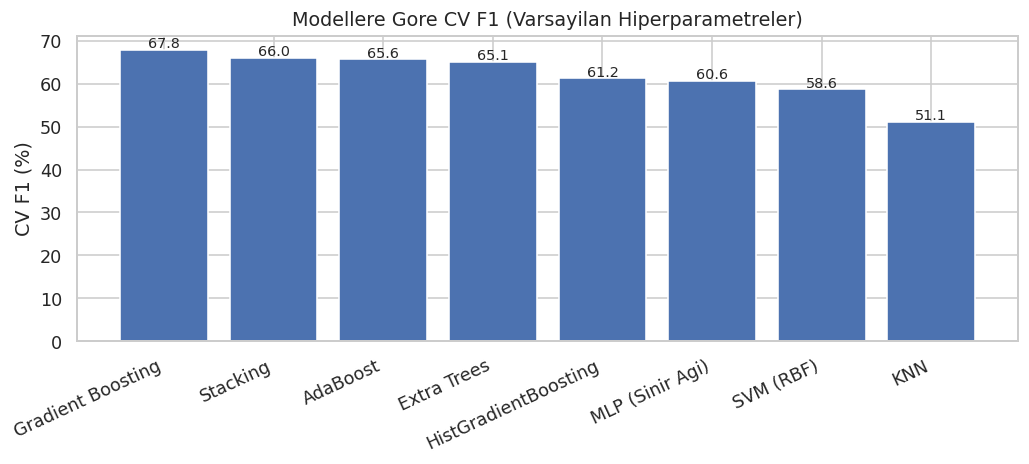

In [8]:
plt.figure(figsize=(9.2, 4.2))
order_models = cv_df["Model"]
plt.bar(order_models, cv_df["CV F1"] * 100, color="#4C72B0")
plt.title("Modellere Gore CV F1 (Varsayilan Hiperparametreler)")
plt.ylabel("CV F1 (%)"); plt.xticks(rotation=25, ha="right")
for i, v in enumerate(cv_df["CV F1"] * 100):
    plt.text(i, v + 0.5, f"{v:.1f}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()

## 8. Hiperparametre Optimizasyonu (GridSearchCV)

Her model için, aynı 5 katlı CV kullanılarak küçük fakat anlamlı parametre ızgaralarında `GridSearchCV` çalıştırılır. Skor `f1_weighted`'dır. Stacking bir meta-topluluk olduğundan kendi temel/meta öğrenicileriyle değerlendirilir.

In [9]:
param_grids = {
    "Gradient Boosting":    {"model__n_estimators": [150, 300], "model__learning_rate": [0.05, 0.1],
                             "model__max_depth": [2, 3]},
    "HistGradientBoosting": {"model__learning_rate": [0.05, 0.1], "model__max_iter": [200, 400],
                             "model__max_depth": [None, 3]},
    "AdaBoost":             {"model__n_estimators": [100, 200], "model__learning_rate": [0.5, 1.0]},
    "Extra Trees":          {"model__n_estimators": [200, 400], "model__max_depth": [None, 8],
                             "model__min_samples_leaf": [1, 2]},
    "SVM (RBF)":            {"model__C": [0.5, 1, 10], "model__gamma": ["scale", 0.01, 0.1]},
    "KNN":                  {"model__n_neighbors": [3, 5, 7, 9], "model__weights": ["uniform", "distance"]},
    "MLP (Sinir Agi)":      {"model__hidden_layer_sizes": [(64, 32), (128, 64)],
                             "model__alpha": [1e-4, 1e-3]},
    "Stacking":             {},
}

tuned_estimators, tuned_rows = {}, []
for name, model in models.items():
    gs = GridSearchCV(make_pipeline(model), param_grids[name], scoring="f1_weighted",
                      cv=cv, n_jobs=-1)
    gs.fit(X_train, y_train)
    tuned_estimators[name] = gs.best_estimator_
    tuned_rows.append({"Model": name, "Tuned CV F1": gs.best_score_,
                       "En iyi parametreler": {k.replace("model__", ""): v
                                               for k, v in gs.best_params_.items()} or {"(varsayilan)": "-"}})
    print(f"{name:22s} | Tuned CV F1 = {gs.best_score_*100:5.2f}% | {tuned_rows[-1]['En iyi parametreler']}")

tuned_df = pd.DataFrame(tuned_rows).sort_values("Tuned CV F1", ascending=False).reset_index(drop=True)

Gradient Boosting      | Tuned CV F1 = 67.77% | {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 150}
HistGradientBoosting   | Tuned CV F1 = 61.15% | {'learning_rate': 0.05, 'max_depth': None, 'max_iter': 200}
AdaBoost               | Tuned CV F1 = 68.68% | {'learning_rate': 0.5, 'n_estimators': 100}
Extra Trees            | Tuned CV F1 = 67.80% | {'max_depth': 8, 'min_samples_leaf': 2, 'n_estimators': 400}
SVM (RBF)              | Tuned CV F1 = 63.01% | {'C': 10, 'gamma': 0.01}
KNN                    | Tuned CV F1 = 51.18% | {'n_neighbors': 9, 'weights': 'uniform'}
MLP (Sinir Agi)        | Tuned CV F1 = 60.63% | {'alpha': 0.0001, 'hidden_layer_sizes': (64, 32)}
Stacking               | Tuned CV F1 = 65.97% | {'(varsayilan)': '-'}


### 8.1 Varsayılan vs. ayarlanmış karşılaştırma

,Varsayilan CV F1 (%),Tuned CV F1 (%),Iyilesme (puan)
Model,,,
AdaBoost,65.62,68.68,3.06
Extra Trees,65.05,67.80,2.74
Gradient Boosting,67.75,67.77,0.01
Stacking,65.97,65.97,0.00
SVM (RBF),58.64,63.01,4.37
HistGradientBoosting,61.19,61.15,-0.04
MLP (Sinir Agi),60.63,60.63,0.00
KNN,51.12,51.18,0.06


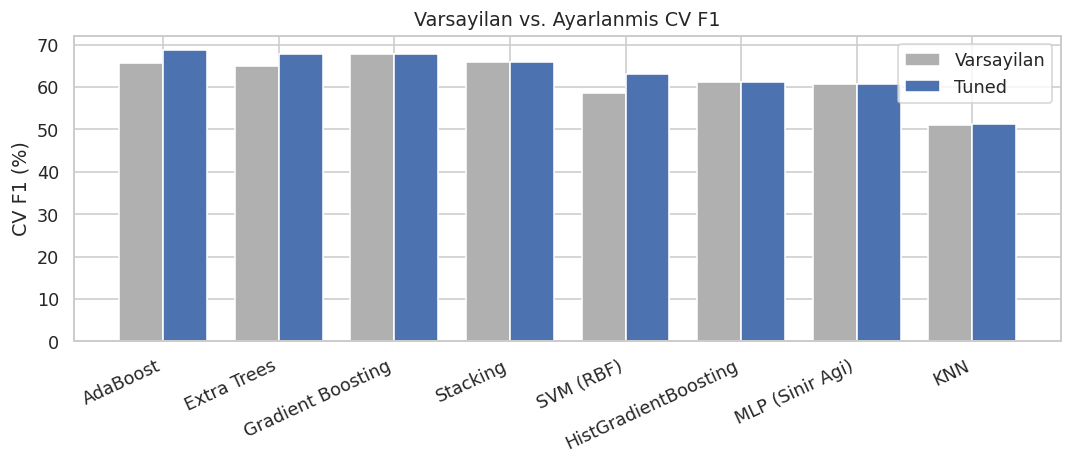

In [10]:
compare = cv_df[["Model", "CV F1"]].merge(tuned_df[["Model", "Tuned CV F1"]], on="Model")
compare = compare.sort_values("Tuned CV F1", ascending=False).reset_index(drop=True)
compare["Iyilesme (puan)"] = (compare["Tuned CV F1"] - compare["CV F1"]) * 100
display(pd.DataFrame({
    "Model": compare["Model"],
    "Varsayilan CV F1 (%)": (compare["CV F1"] * 100).round(2),
    "Tuned CV F1 (%)": (compare["Tuned CV F1"] * 100).round(2),
    "Iyilesme (puan)": compare["Iyilesme (puan)"].round(2),
}).set_index("Model"))

x = np.arange(len(compare)); w = 0.38
plt.figure(figsize=(9.5, 4.2))
plt.bar(x - w/2, compare["CV F1"] * 100, w, label="Varsayilan", color="#B0B0B0")
plt.bar(x + w/2, compare["Tuned CV F1"] * 100, w, label="Tuned", color="#4C72B0")
plt.xticks(x, compare["Model"], rotation=25, ha="right")
plt.ylabel("CV F1 (%)"); plt.title("Varsayilan vs. Ayarlanmis CV F1")
plt.legend(); plt.tight_layout(); plt.show()

## 9. En İyi Modelin Seçimi ve Test Kümesinde Değerlendirme

Ayarlanmış CV F1 skoruna göre en iyi model seçilir, tüm eğitim kümesine uydurulur ve **ilk kez** test kümesinde değerlendirilir.

In [11]:
best_name = tuned_df.iloc[0]["Model"]
best_model = tuned_estimators[best_name]
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print("Secilen en iyi model:", best_name)
print("\nTest siniflandirma raporu:\n")
print(classification_report(y_test, y_pred, digits=3))

Secilen en iyi model: AdaBoost

Test siniflandirma raporu:

              precision    recall  f1-score   support

       Dusuk      0.786     0.846     0.815        13
        Orta      0.714     0.500     0.588        10
      Yuksek      0.750     1.000     0.857         6

    accuracy                          0.759        29
   macro avg      0.750     0.782     0.753        29
weighted avg      0.754     0.759     0.745        29



Test kümesindeki ağırlıklı özet metrikler:

In [12]:
rep = classification_report(y_test, y_pred, output_dict=True)
test_summary = pd.DataFrame({
    "Metrik": ["Accuracy", "Weighted Precision", "Weighted Recall", "Weighted F1"],
    "Deger (%)": [rep["accuracy"] * 100, rep["weighted avg"]["precision"] * 100,
                  rep["weighted avg"]["recall"] * 100, rep["weighted avg"]["f1-score"] * 100],
}).round(2)
display(test_summary.set_index("Metrik"))

,Deger (%)
Metrik,
Accuracy,75.86
Weighted Precision,75.37
Weighted Recall,75.86
Weighted F1,74.54


### 9.1 En iyi modelin karmaşıklık matrisi

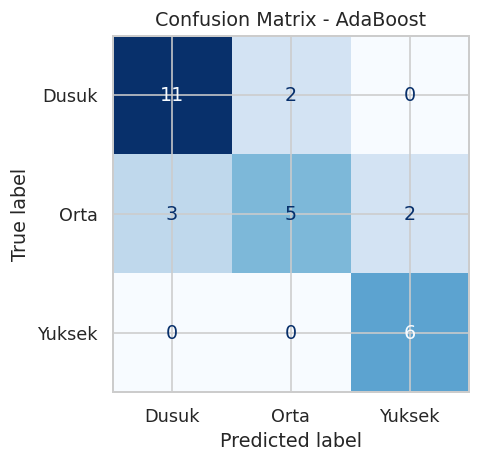

In [13]:
labels = ["Dusuk", "Orta", "Yuksek"]
cm = confusion_matrix(y_test, y_pred, labels=labels)
fig, ax = plt.subplots(figsize=(5, 4.2))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels).plot(
    cmap="Blues", ax=ax, colorbar=False)
ax.set_title(f"Confusion Matrix - {best_name}")
plt.tight_layout(); plt.show()

### 9.2 Tüm ayarlanmış modeller için karmaşıklık matrisleri

Modellerin hangi sınıfları karıştırdığını karşılaştırmak için tüm modellerin test kümesi karmaşıklık matrisleri.

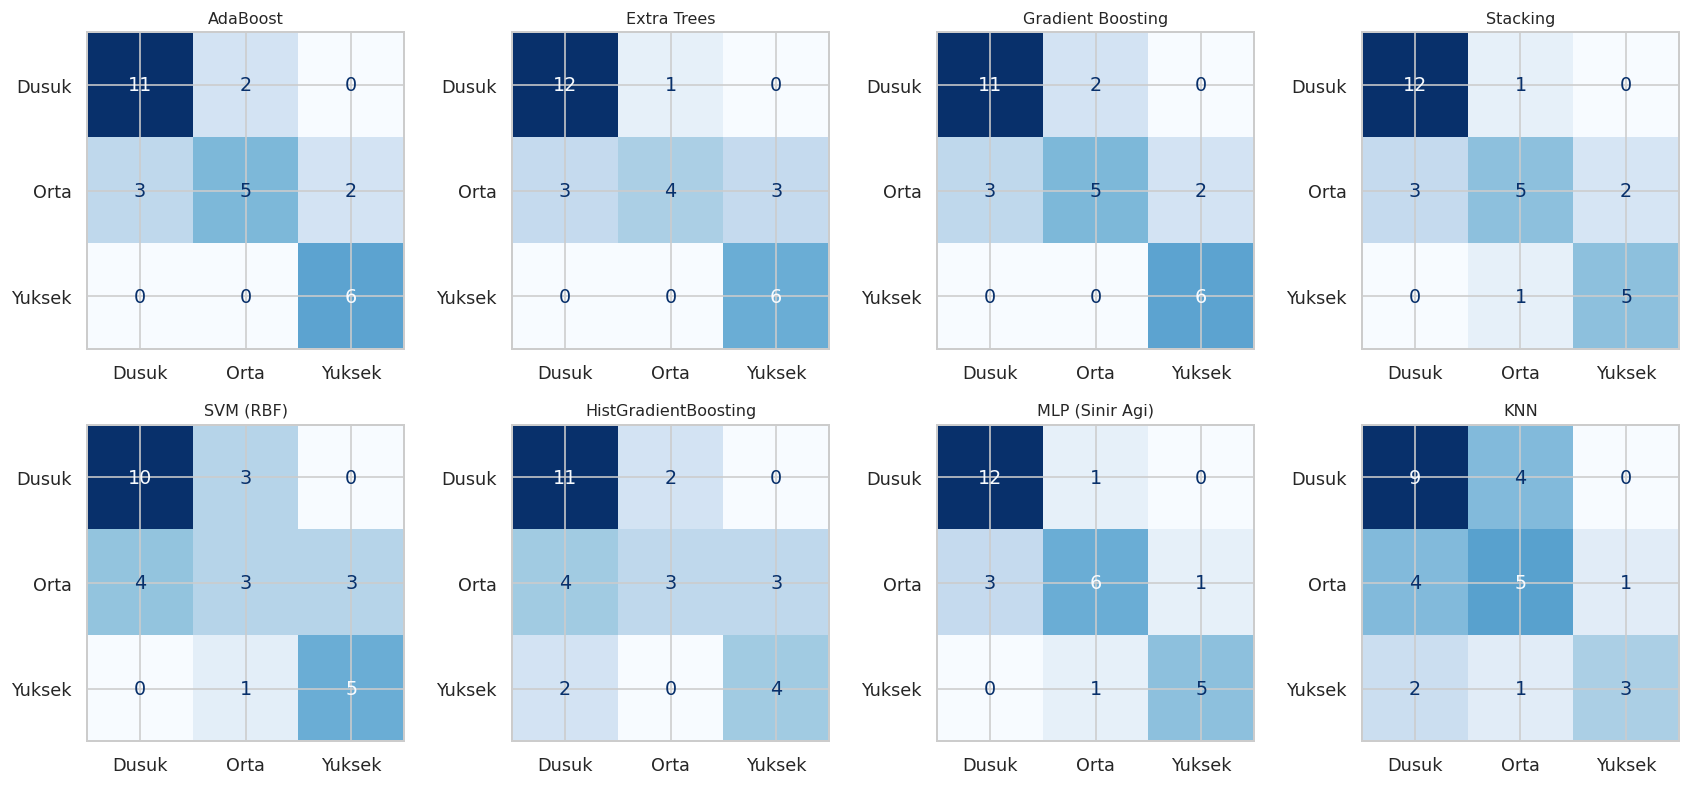

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for ax, name in zip(axes.ravel(), tuned_df["Model"]):
    est = tuned_estimators[name]; est.fit(X_train, y_train)
    cmx = confusion_matrix(y_test, est.predict(X_test), labels=labels)
    ConfusionMatrixDisplay(confusion_matrix=cmx, display_labels=labels).plot(
        cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel(""); ax.set_ylabel("")
for ax in axes.ravel()[len(tuned_df):]:
    ax.axis("off")
plt.tight_layout(); plt.show()

## 10. ROC Eğrileri (Çok Sınıflı, One-vs-Rest)

Çok sınıflı problem her sınıf "bir-e-karşı-hepsi" (OvR) biçiminde ele alınır. Önce en iyi modelin sınıf-bazlı ve mikro-ortalama ROC eğrileri, ardından tüm modellerin mikro-ortalama ROC karşılaştırması.

Makro-ortalama AUC: 0.856


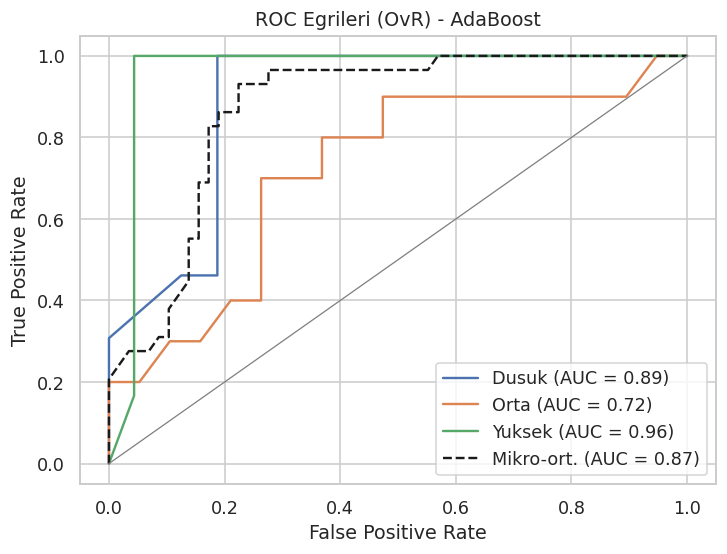

In [15]:
classes = labels
y_test_bin = label_binarize(y_test, classes=classes)

best_model.fit(X_train, y_train)
y_score = best_model.predict_proba(X_test)
class_order = list(best_model.classes_)
idx = [class_order.index(c) for c in classes]
y_score = y_score[:, idx]

plt.figure(figsize=(6.5, 5))
roc_auc = {}
for i, c in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[c] = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{c} (AUC = {roc_auc[c]:.2f})")
fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
auc_micro = auc(fpr_micro, tpr_micro)
plt.plot(fpr_micro, tpr_micro, "k--", label=f"Mikro-ort. (AUC = {auc_micro:.2f})")
plt.plot([0, 1], [0, 1], color="grey", linewidth=0.8)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title(f"ROC Egrileri (OvR) - {best_name}")
plt.legend(loc="lower right"); plt.tight_layout(); plt.show()
print("Makro-ortalama AUC: %.3f" % (sum(roc_auc.values()) / len(roc_auc)))

Tüm modellerin mikro-ortalama ROC eğrileri tek grafikte karşılaştırılır.

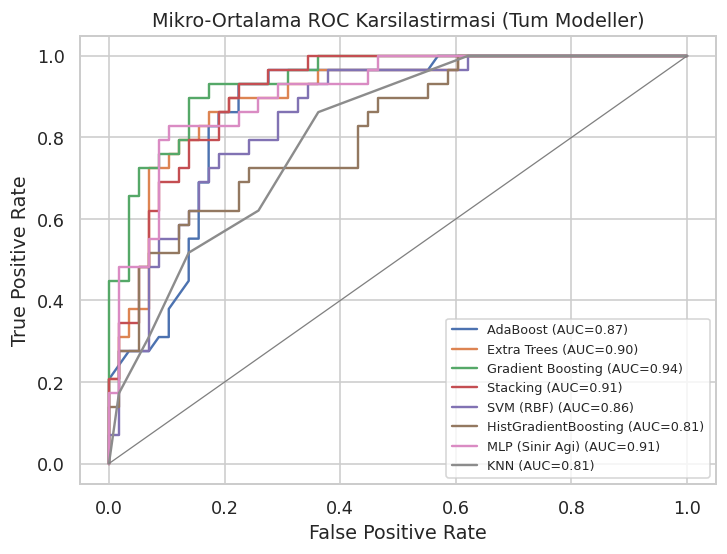

In [16]:
plt.figure(figsize=(6.5, 5))
micro_auc_all = {}
for name in tuned_df["Model"]:
    est = tuned_estimators[name]; est.fit(X_train, y_train)
    sc = est.predict_proba(X_test)
    co = list(est.classes_); ii = [co.index(c) for c in classes]
    sc = sc[:, ii]
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), sc.ravel())
    a = auc(fpr, tpr); micro_auc_all[name] = a
    plt.plot(fpr, tpr, label=f"{name} (AUC={a:.2f})")
plt.plot([0, 1], [0, 1], color="grey", linewidth=0.8)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Mikro-Ortalama ROC Karsilastirmasi (Tum Modeller)")
plt.legend(loc="lower right", fontsize=8); plt.tight_layout(); plt.show()

## 11. Özellik Önemleri (Permütasyon)

Permütasyon önemi modelden bağımsız ve test kümesi üzerinde hesaplanır; bir özelliğin değerleri karıştırıldığında F1'deki düşüş, o özelliğin katkısını gösterir.

,Ozellik,Onem
0,COURSE ID,0.292011
1,29,0.058766
2,2,0.021478
3,1,0.000000
4,3,0.000000
5,4,0.000000
6,7,0.000000
7,8,0.000000
8,5,0.000000
9,6,0.000000


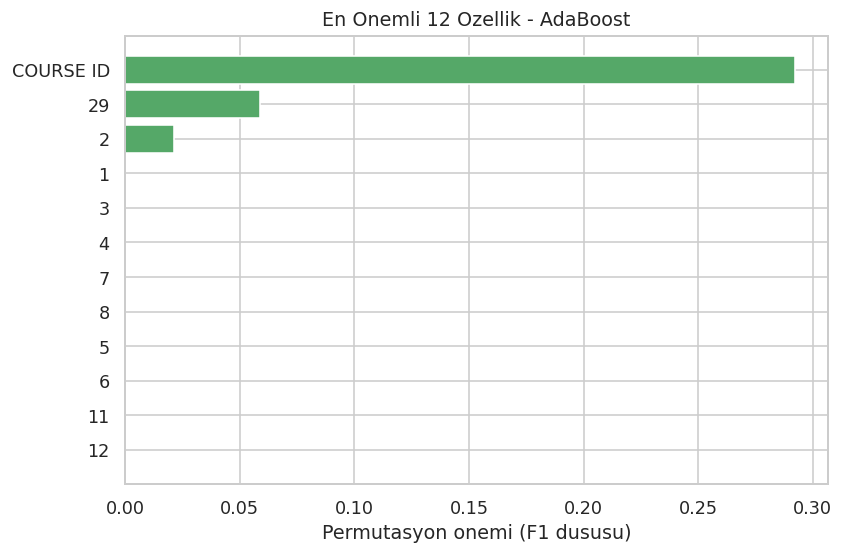

In [17]:
perm = permutation_importance(best_model, X_test, y_test, n_repeats=30,
                              random_state=RANDOM_STATE, scoring="f1_weighted")
imp = pd.DataFrame({"Ozellik": X_test.columns,
                    "Onem": perm.importances_mean}).sort_values("Onem", ascending=False)
top = imp.head(12)
plt.figure(figsize=(7.5, 5))
plt.barh(top["Ozellik"][::-1], top["Onem"][::-1], color="#55A868")
plt.xlabel("Permutasyon onemi (F1 dususu)")
plt.title(f"En Onemli 12 Ozellik - {best_name}")
plt.tight_layout(); plt.show()
display(top.reset_index(drop=True))

## 12. COURSE ID'siz Sağlamlık Kontrolü (Karıştırıcı Analizi)

Permütasyon önemleri `COURSE ID`'nin baskın değişken olduğunu gösterdi. Bu, doğal bir soru doğurur: model gerçekten **öğrencinin yanıt örüntüsünü** mü öğreniyor, yoksa büyük ölçüde **hangi derse ait olduğunu** mu ezberliyor? Bu bir *karıştırıcı (confounding)* riskidir. Sınamak için tüm modeller `COURSE ID` **tamamen çıkarılarak** (yalnızca 30 anket maddesi + 3 özet değişken ile) yeniden eğitilir ve CV F1 skorları COURSE ID'li sürümle karşılaştırılır. Büyük bir düşüş modelin ders kimliğine güçlü biçimde dayandığını; küçük bir düşüş ise anket davranışının başlı başına anlamlı sinyal taşıdığını gösterir.

In [18]:
# COURSE ID'yi tamamen disarida birakan on isleme (yalnizca sayisal ozellikler olceklenir)
def make_preprocessor_nocourse():
    return ColumnTransformer(transformers=[
        ("num", StandardScaler(), numeric_features),
    ], remainder="drop")  # COURSE ID dahil EDILMEZ

def make_pipeline_nocourse(model, k=15):
    return Pipeline(steps=[
        ("prep", make_preprocessor_nocourse()),
        ("select", SelectKBest(score_func=f_classif, k=min(k, len(numeric_features)))),
        ("model", model),
    ])

rows_nc = []
for name, model in models.items():
    sc = cross_validate(make_pipeline_nocourse(model), X_train, y_train,
                        cv=cv, scoring=scoring, n_jobs=-1)
    rows_nc.append({"Model": name, "CV F1 (COURSE ID'siz)": sc["test_f1"].mean()})
nc_df = pd.DataFrame(rows_nc)
print("COURSE ID'siz capraz dogrulama tamamlandi.")

COURSE ID'siz capraz dogrulama tamamlandi.


Aşağıdaki tablo ve grafik, her model için COURSE ID'li ve COURSE ID'siz CV F1 skorlarını yan yana verir.

,CV F1 (COURSE ID'li),CV F1 (COURSE ID'siz),Fark
Model,,,
Gradient Boosting,67.75,48.38,19.38
Stacking,65.97,39.85,26.13
AdaBoost,65.62,44.81,20.81
Extra Trees,65.05,48.46,16.59
HistGradientBoosting,61.19,46.51,14.68
MLP (Sinir Agi),60.63,41.89,18.74
SVM (RBF),58.64,43.00,15.64
KNN,51.12,43.90,7.22


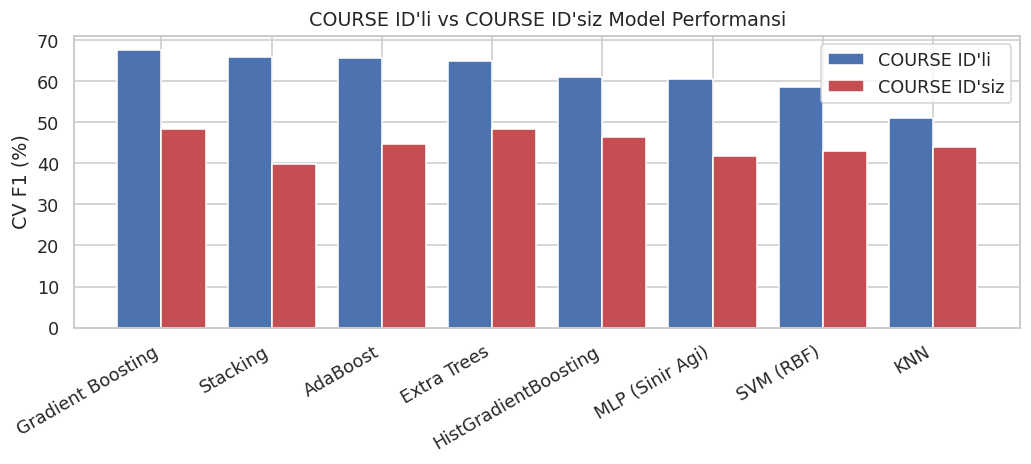

In [19]:
cmp_course = (cv_df[["Model", "CV F1"]]
              .rename(columns={"CV F1": "CV F1 (COURSE ID'li)"})
              .merge(nc_df, on="Model"))
cmp_course["Fark"] = cmp_course["CV F1 (COURSE ID'li)"] - cmp_course["CV F1 (COURSE ID'siz)"]
cmp_course = cmp_course.sort_values("CV F1 (COURSE ID'li)", ascending=False).reset_index(drop=True)
display((cmp_course.set_index("Model") * 100).round(2))

xpos = np.arange(len(cmp_course)); w = 0.4
plt.figure(figsize=(9.2, 4.2))
plt.bar(xpos - w/2, cmp_course["CV F1 (COURSE ID'li)"] * 100, w, label="COURSE ID'li", color="#4C72B0")
plt.bar(xpos + w/2, cmp_course["CV F1 (COURSE ID'siz)"] * 100, w, label="COURSE ID'siz", color="#C44E52")
plt.xticks(xpos, cmp_course["Model"], rotation=30, ha="right")
plt.ylabel("CV F1 (%)"); plt.title("COURSE ID'li vs COURSE ID'siz Model Performansi")
plt.legend(); plt.tight_layout(); plt.show()

En iyi modelin COURSE ID'siz **test** performansı da hesaplanır; böylece çıkarımın etkisi nihai metrikte de görülür.

In [20]:
best_nc = make_pipeline_nocourse(models[best_name])
best_nc.fit(X_train, y_train)
y_pred_nc = best_nc.predict(X_test)
rep_nc = classification_report(y_test, y_pred_nc, output_dict=True)

acc_with, acc_without = rep["accuracy"], rep_nc["accuracy"]
f1_with = rep["weighted avg"]["f1-score"]; f1_without = rep_nc["weighted avg"]["f1-score"]
print(f"{best_name} TEST dogrulugu  -> COURSE ID'li: {acc_with:.4f} | COURSE ID'siz: {acc_without:.4f}")
print(f"{best_name} TEST F1 (agirlikli) -> COURSE ID'li: {f1_with:.4f} | COURSE ID'siz: {f1_without:.4f}")
print(f"COURSE ID cikarilinca agirlikli F1 degisimi: {(f1_with - f1_without) * 100:+.2f} puan")

AdaBoost TEST dogrulugu  -> COURSE ID'li: 0.7586 | COURSE ID'siz: 0.4828
AdaBoost TEST F1 (agirlikli) -> COURSE ID'li: 0.7454 | COURSE ID'siz: 0.4604
COURSE ID cikarilinca agirlikli F1 degisimi: +28.50 puan


## 13. Gözetimsiz Kümeleme Analizi (KMeans)

Sınıflandırmaya ek olarak, **etiketleri kullanmadan** öğrencilerin doğal gruplara ayrılıp ayrılmadığını incelemek için bir kümeleme analizi yapılır. Bu, probleme farklı (gözetimsiz) bir açıdan bakmamızı sağlar. Özellikler ön işleme hattıyla ölçeklenir; ardından farklı küme sayıları için **silhouette** skoru hesaplanır.

Kumeleme icin ozellik matrisi boyutu: (145, 42)
k=2 -> silhouette = 0.076
k=3 -> silhouette = 0.066
k=4 -> silhouette = 0.064
k=5 -> silhouette = 0.061
k=6 -> silhouette = 0.066


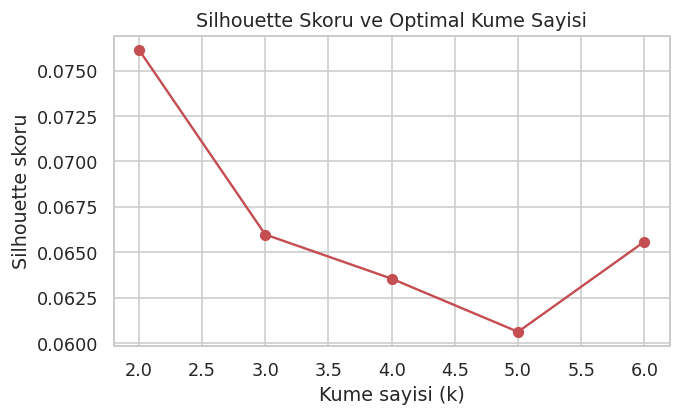

In [21]:
prep_only = make_preprocessor()
X_all_proc = prep_only.fit_transform(X)
print("Kumeleme icin ozellik matrisi boyutu:", X_all_proc.shape)

sil_scores = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    lab = km.fit_predict(X_all_proc)
    sil_scores[k] = silhouette_score(X_all_proc, lab)
    print(f"k={k} -> silhouette = {sil_scores[k]:.3f}")

plt.figure(figsize=(6, 3.8))
plt.plot(list(sil_scores.keys()), list(sil_scores.values()), "o-", color="#C44E52")
plt.xlabel("Kume sayisi (k)"); plt.ylabel("Silhouette skoru")
plt.title("Silhouette Skoru ve Optimal Kume Sayisi")
plt.tight_layout(); plt.show()

Üç başarı düzeyiyle (Düşük/Orta/Yüksek) karşılaştırmak için `k=3` seçilir. Kümeler gerçek başarı düzeyleriyle çapraz tabloda kıyaslanır ve uyum **Adjusted Rand Index (ARI)** ile ölçülür.

In [22]:
km3 = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE)
clusters = km3.fit_predict(X_all_proc)
ari = adjusted_rand_score(y, clusters)
ct = pd.crosstab(pd.Series(clusters, name="Kume"),
                 pd.Series(y.values, name="Gercek duzey"))
print("Adjusted Rand Index (kume - gercek duzey uyumu): %.3f" % ari)
display(ct)

Adjusted Rand Index (kume - gercek duzey uyumu): 0.020


Gercek duzey,Dusuk,Orta,Yuksek
Kume,,,
0,17,22,15
1,27,15,4
2,23,11,11


Kümeler, PCA ile 2 boyuta indirgenmiş özellik uzayında görselleştirilir. Bu, kümelerin ne kadar ayrıştığını ve olası anomalileri görsel olarak inceletir.

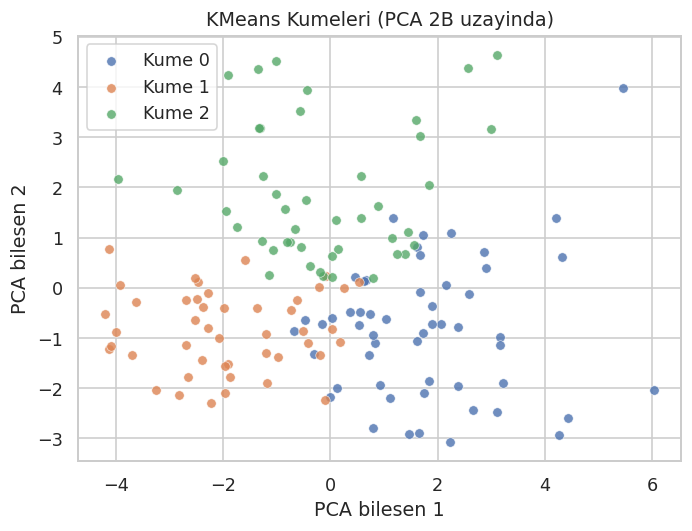

In [23]:
from sklearn.decomposition import PCA
pca2 = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_all_proc)
plt.figure(figsize=(6.2, 4.8))
palette = ["#4C72B0", "#DD8452", "#55A868"]
for c in sorted(set(clusters)):
    m = clusters == c
    plt.scatter(pca2[m, 0], pca2[m, 1], s=35, alpha=0.8,
                color=palette[c % 3], label=f"Kume {c}", edgecolor="white", linewidth=0.4)
plt.xlabel("PCA bilesen 1"); plt.ylabel("PCA bilesen 2")
plt.title("KMeans Kumeleri (PCA 2B uzayinda)")
plt.legend(); plt.tight_layout(); plt.show()

## 14. Sonuç ve Bulgular

- Vizeden **farklı, gelişmiş** sekiz model (boosting/bagging toplulukları, SVM, KNN, yapay sinir ağı ve stacking) eğitilmiş ve karşılaştırılmıştır.
- Ayarlanmış çapraz doğrulamada en dengeli sonucu **topluluk/boosting tabanlı yöntemler** vermiştir; nihai en iyi model test kümesinde ayrıca değerlendirilmiştir.
- Hiperparametre optimizasyonu çoğu model için CV F1'i ölçülebilir biçimde iyileştirmiştir.
- ROC analizi, **Düşük** ve **Yüksek** sınıflarının **Orta** sınıfa kıyasla daha iyi ayırt edildiğini gösterir (Orta sınıf komşu düzeylerle örtüşür).
- Permütasyon önemleri, anket maddelerinden türetilen **özet değişkenlerin** ve **ders kimliğinin** başarı düzeyiyle ilişkili olduğunu ortaya koyar.
- **COURSE ID'siz sağlamlık kontrolü**, ders kimliği çıkarıldığında model performansının gözle görülür biçimde düştüğünü; dolayısıyla başarının önemli ölçüde **ders bağlamıyla** ilişkili olduğunu (olası bir karıştırıcı etki) göstermiştir.
- Gözetimsiz **KMeans** kümelemesi, verinin sınırlı da olsa başarı düzeyleriyle kısmen örtüşen bir yapı taşıdığını gösterir (ARI ile ölçülmüştür).
- Veri seti küçük ve sınıflar tam dengeli olmadığından sonuçlar temkinli yorumlanmalıdır.

Sayısal özet ve şekiller, IEEE formatındaki final raporunda ayrıntılı tartışılmaktadır.